In [ ]:
pip install shap

In [3]:
# 1. Importar librerías
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import shap
import mlflow
import mlflow.tensorflow

# 2. Cargar datos ya codificados
df = pd.read_csv("df_encoded.csv")

# 3. Separar características y etiqueta
X = df.drop("puntaje_cat", axis=1)
y = df["puntaje_cat"]

# 4. Dividir en entrenamiento, validación y prueba
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=100)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=100)

# 5. Construir modelo con una entrada vectorial
def build_dense_model(input_shape, layer_units):
    inputs = keras.Input(shape=(input_shape,))
    x = inputs
    for units in layer_units:
        x = keras.layers.Dense(units, activation='relu')(x)
    output = keras.layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs, output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 6. Entrenar el modelo con MLflow
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("red_neuronal_vectorial")

arquitectura = [64, 32]

with mlflow.start_run():
    mlflow.log_param("arquitectura", arquitectura)
    mlflow.tensorflow.autolog()

    model = build_dense_model(X_train.shape[1], arquitectura)
    model.fit(X_train.values, y_train.values, 
              validation_data=(X_val.values, y_val.values), 
              epochs=20, batch_size=32)

    loss, accuracy = model.evaluate(X_test.values, y_test.values)
    mlflow.log_metric("test_loss", loss)
    mlflow.log_metric("test_accuracy", accuracy)

    model.save("modelo_vectorial.h5")
    mlflow.log_artifact("modelo_vectorial.h5")

    # Evaluación final
    y_pred_prob = model.predict(X_test.values)
    y_pred = (y_pred_prob > 0.5).astype(int)
    report = classification_report(y_test, y_pred, output_dict=True)
    mlflow.log_dict(report, "classification_report.json")

# 7. Interpretar con SHAP
explainer = shap.DeepExplainer(model, X_train.values[:100])  # background
shap_values = explainer.shap_values(X_test.values[:100])

# 8. Gráfico resumen
shap.summary_plot(shap_values[0], X_test.values[:100], feature_names=X.columns)


Epoch 1/20
9523/9528 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7029 - loss: 0.5615

9528/9528 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accuracy: 0.7029 - loss: 0.5615 - val_accuracy: 0.7080 - val_loss: 0.5535
Epoch 2/20
9527/9528 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7112 - loss: 0.5509

9528/9528 ━━━━━━━━━━━━━━━━━━━━ 76s 7ms/step - accuracy: 0.7112 - loss: 0.5509 - val_accuracy: 0.7096 - val_loss: 0.5509
Epoch 3/20
9528/9528 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7122 - loss: 0.5486

9528/9528 ━━━━━━━━━━━━━━━━━━━━ 72s 8ms/step - accuracy: 0.7122 - loss: 0.5486 - val_accuracy: 0.7099 - val_loss: 0.5508
Epoch 4/20
9528/9528 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7141 - loss: 0.5470

9528/9528 ━━━━━━━━━━━━━━━━━━━━ 59s 5ms/step - accuracy: 0.7141 - loss: 0.5470 - val_accuracy: 0.7114 - val_loss: 0.5489
Epoch 5/20
9528/9528 ━━━━━━━━━━━━━━━━━━━━ 90s 6ms/step - accuracy: 0.7154 - loss: 0.5450 - val_accuracy: 0.7110 - val_loss: 0.5493
Epoch 6/20
9528/9528 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - accuracy: 0.7151 - loss: 0.5452 - val_accuracy: 0.7112 - val_loss: 0.5495
Epoch 7/20
9528/9528 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.7151 - loss: 0.5445 - val_accuracy: 0.7109 - val_loss: 0.5497
Epoch 8/20
9528/9528 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.7171 - loss: 0.5416 - val_accuracy: 0.7112 - val_loss: 0.5490
Epoch 9/20
9528/9528 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - accuracy: 0.7183 - loss: 0.5411 - val_accuracy: 0.7104 - val_loss: 0.5517
Epoch 10/20
9528/9528 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.7189 - loss: 0.5399 - val_accuracy: 0.7107 - val_loss: 0.5507
Epoch 11/20
9528/9528 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - accuracy: 0.7185 - loss: 0.5397 - v

2978/2978 ━━━━━━━━━━━━━━━━━━━━ 1s 483us/step
🏃 View run inquisitive-crab-494 at: http://localhost:5000/#/experiments/389121594392664938/runs/c5ec672b50a54075a9909d34a1fe7091
🧪 View experiment at: http://localhost:5000/#/experiments/389121594392664938


c:\Users\sexto\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
c:\Users\sexto\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_112
Received: inputs=['Tensor(shape=(100, 100))']
  warnings.warn(msg)
c:\Users\sexto\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_112
Received: inputs=['Tensor(shape=(200, 100))']
  warnings.warn(msg)


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

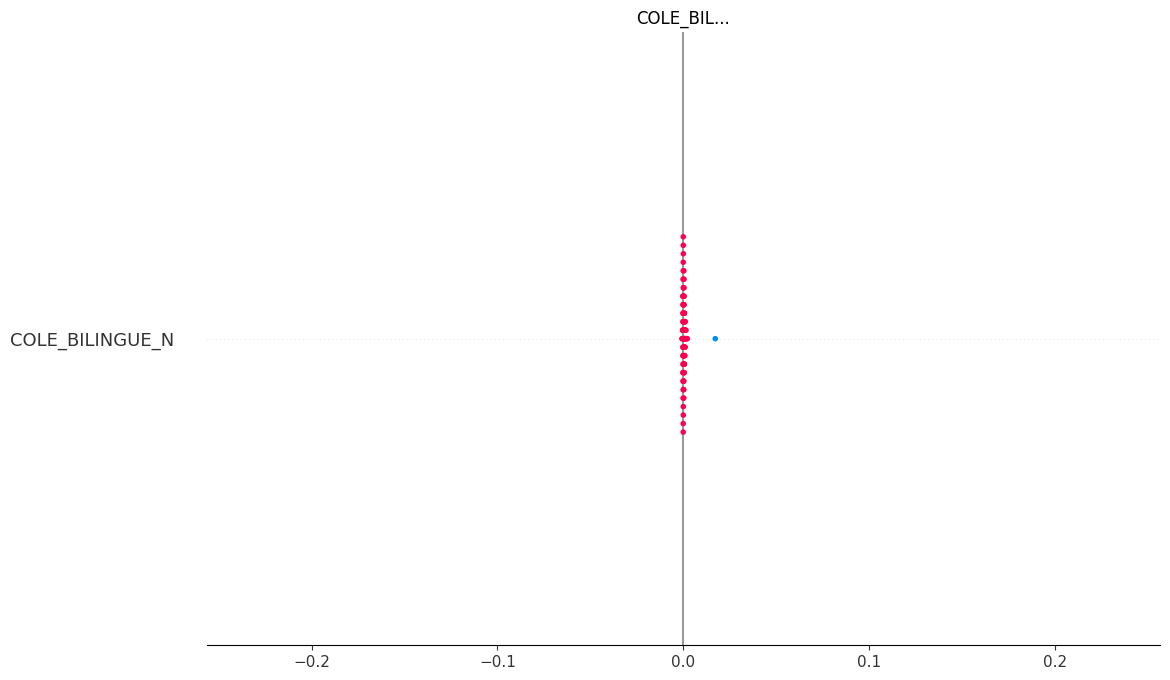

In [4]:
shap.summary_plot(shap_values, X_test.values[:100], feature_names=X.columns)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


  0%|          | 0/10 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
3447/3447 ━━━━━━━━━━━━━━━━━━━━ 2s 494us/step


 10%|█         | 1/10 [00:02<00:22,  2.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
3447/3447 ━━━━━━━━━━━━━━━━━━━━ 2s 452us/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3447/3447 ━━━━━━━━━━━━━━━━━━━━ 1s 412us/step


 90%|█████████ | 9/10 [00:19<00:02,  2.13s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3450/3450 ━━━━━━━━━━━━━━━━━━━━ 1s 410us/step


100%|██████████| 10/10 [00:21<00:00,  2.19s/it]


<Figure size 640x480 with 0 Axes>

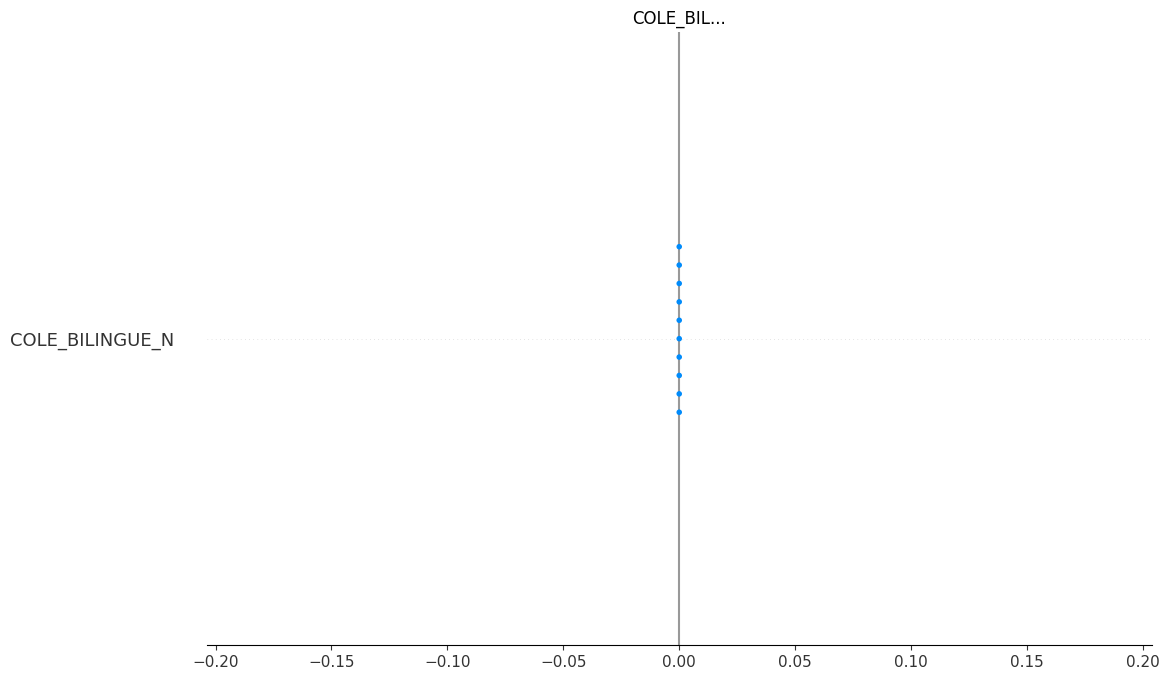

In [5]:
explainer = shap.KernelExplainer(model.predict, X_train.values[:50])
shap_values = explainer.shap_values(X_test.values[:10])
shap.summary_plot(shap_values, X_test.values[:10], feature_names=X.columns)


In [6]:
print(X.shape)           # ¿Cuántas variables tiene en total?
print(X.columns.tolist())  # ¿Cuáles son?
print(X_test.shape)


(476354, 100)
['COLE_BILINGUE_N', 'COLE_BILINGUE_S', 'COLE_CALENDARIO_A', 'COLE_CALENDARIO_B', 'COLE_CALENDARIO_OTRO', 'COLE_CARACTER_ACADÉMICO', 'COLE_CARACTER_NO APLICA', 'COLE_CARACTER_TÉCNICO', 'COLE_CARACTER_TÉCNICOACADÉMICO', 'COLE_GENERO_FEMENINO', 'COLE_GENERO_MASCULINO', 'COLE_GENERO_MIXTO', 'COLE_JORNADA_COMPLETA', 'COLE_JORNADA_MAÑANA', 'COLE_JORNADA_NOCHE', 'COLE_JORNADA_SABATINA', 'COLE_JORNADA_TARDE', 'COLE_JORNADA_UNICA', 'ESTU_DEPTO_RESIDE_antioquia', 'ESTU_DEPTO_RESIDE_arauca', 'ESTU_DEPTO_RESIDE_atlantico', 'ESTU_DEPTO_RESIDE_bogota', 'ESTU_DEPTO_RESIDE_bolivar', 'ESTU_DEPTO_RESIDE_boyaca', 'ESTU_DEPTO_RESIDE_caldas', 'ESTU_DEPTO_RESIDE_caqueta', 'ESTU_DEPTO_RESIDE_casanare', 'ESTU_DEPTO_RESIDE_cauca', 'ESTU_DEPTO_RESIDE_cesar', 'ESTU_DEPTO_RESIDE_choco', 'ESTU_DEPTO_RESIDE_cordoba', 'ESTU_DEPTO_RESIDE_cundinamarca', 'ESTU_DEPTO_RESIDE_huila', 'ESTU_DEPTO_RESIDE_la guajira', 'ESTU_DEPTO_RESIDE_magdalena', 'ESTU_DEPTO_RESIDE_meta', 'ESTU_DEPTO_RESIDE_narino', 'ESTU_DEP

C:\Users\sexto\AppData\Local\Temp\ipykernel_18232\180634242.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values, X_sample)


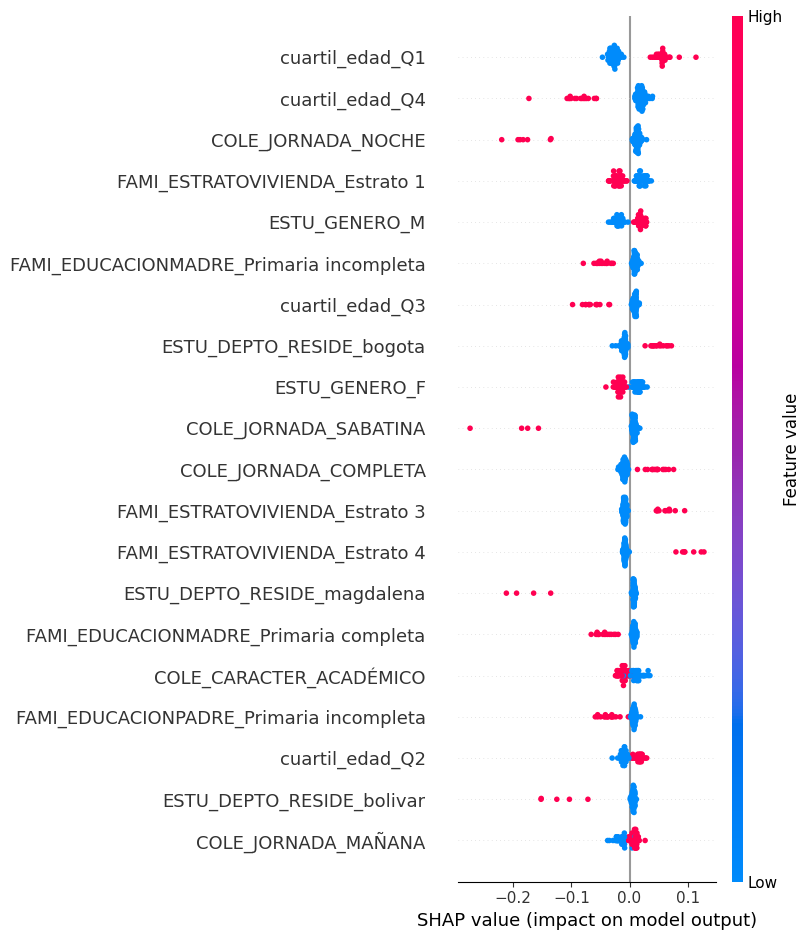

In [8]:
# Asegúrate de que el explainer y el SHAP se calculen sobre el mismo subconjunto
X_sample = X_test[:100]  # un DataFrame con 100 filas

explainer = shap.Explainer(model, X_sample)
shap_values = explainer(X_sample)

shap.summary_plot(shap_values.values, X_sample)


AssertionError: Feature and SHAP matrices must have the same number of rows!

<Figure size 640x480 with 0 Axes>

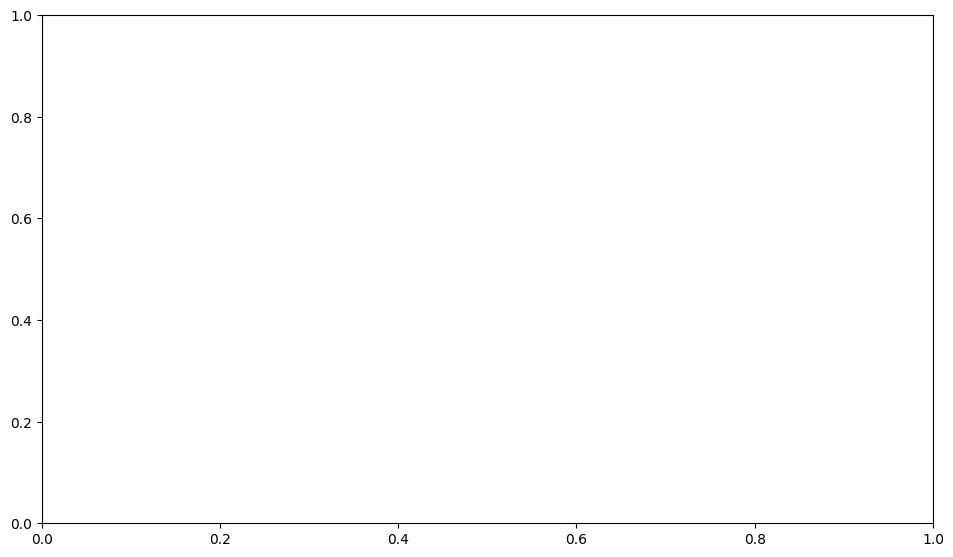

In [7]:
shap.summary_plot(shap_values, pd.DataFrame(X_test.values[:100], columns=X.columns))
